# Dimensionality Reduction

This notebook implements the **Dimensionality Reduction** stage of the CRISP-DM methodology for the *Mental Health in Technology-related Jobs* project.

Notebook 02 produced the canonical prepared analytical matrix from the OSMI Mental Health in Tech 2016 survey. That representation contains 1,433 respondents and a substantially larger number of numerical features than the original survey because categorical responses were encoded numerically and the multi-response work-position field was decomposed into binary indicators.

This notebook therefore **does not repeat data cleaning, feature engineering, imputation, or categorical encoding**. It begins from the prepared analytical dataset created in Notebook 02.

The objective is to determine whether the prepared feature space can be represented using substantially fewer dimensions while preserving meaningful structure for the clustering experiments that follow.

The analysis focuses on:

- reducing redundant features before feature extraction;
- standardizing the selected numerical representation;
- evaluating **Principal Component Analysis (PCA)** as the primary dimensionality-reduction method;
- examining PCA explained variance and component loadings;
- evaluating **Multidimensional Scaling (MDS)** as a complementary distance-based representation;
- considering **Locally Linear Embedding (LLE)** only if its use is justified by the dataset and methodological requirements;
- preserving the analytical representations required for Notebook 04.

The dimensionality-reduction stage informs the clustering experiments. It does **not** determine the final clustering model or cluster count.

No clustering model is fitted in this notebook.

## 1. Dimensionality-Reduction Objectives

### Question

Can the prepared analytical feature space be represented in substantially fewer dimensions while retaining meaningful structure for subsequent unsupervised analysis?

### Method

The analysis proceeds through the following stages:

1. Load and validate the canonical analytical matrix produced in Notebook 02.
2. Remove any zero-variance features.
3. Identify and remove highly redundant features using correlation analysis.
4. Standardize the selected feature representation.
5. Fit PCA across the complete selected feature space.
6. Examine individual and cumulative explained variance.
7. Determine the PCA representation from the observed cumulative variance structure.
8. Examine the strongest PCA loadings.
9. Visualize the leading PCA dimensions.
10. Evaluate MDS as a complementary distance-based representation.
11. Consider LLE against the characteristics of the prepared data and the coursebook criteria.
12. Save the representations required for the clustering experiments.

### Why

Dimensionality reduction changes the feature space in which later clustering algorithms operate.

The objective is therefore not to produce the smallest possible representation. Instead, the objective is to identify representations that provide meaningful dimensionality reduction while retaining important information and remaining appropriate for subsequent clustering analysis.

The resulting representations will be evaluated further in Notebook 04 rather than being declared optimal solely from dimensionality-reduction results.

In [23]:
# Import the libraries required for data handling, dimensionality reduction,
# visualization, result interpretation, and persistence of analytical outputs.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mental_health_ml.data import load_dataset
from mental_health_ml.dimensionality_reduction import fit_mds, fit_pca
from mental_health_ml.feature_selection import (
    remove_redundant_features,
    remove_zero_variance_features,
)

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
PCA_VARIANCE_THRESHOLD = 0.90
CORRELATION_THRESHOLD = 0.95

## 2. Load the Prepared Analytical Matrix

Notebook 02 produced the canonical processed analytical dataset:

`data/processed/mental_health_prepared.csv`

This file contains the numerical representation resulting from the documented data-preparation decisions.

Loading this artifact keeps the CRISP-DM stages separate and prevents Notebook 03 from silently rebuilding decisions that were already made in Notebook 02.

In [24]:
# Load the canonical analytical matrix produced by Notebook 02
processed_path = Path("../data/processed/mental_health_prepared.csv")

X_prepared = load_dataset(processed_path)

print(
    "Prepared analytical matrix loaded: "
    f"{X_prepared.shape[0]:,} observations x "
    f"{X_prepared.shape[1]} features."
)

Prepared analytical matrix loaded: 1,433 observations x 495 features.


## 3. Analytical Input Validation

### Question

Does the processed analytical matrix satisfy the structural requirements for dimensionality-reduction analysis?

### Validation criteria

The analytical input must:

- contain the respondent count established during data preparation;
- contain numerical features only;
- contain no missing values;
- contain only finite values.

These checks validate the handoff from Notebook 02. They do not repeat the preparation analysis.

In [25]:
# Validate the structural properties required before feature selection
# and dimensionality reduction.
if X_prepared.shape[0] != 1433:
    raise ValueError(
        f"Unexpected respondent count: {X_prepared.shape[0]}. "
        "Expected 1,433 observations."
    )

if not all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in X_prepared.dtypes
):
    raise TypeError(
        "The prepared analytical matrix must contain only numerical features."
    )

if X_prepared.isna().any().any():
    raise ValueError(
        "The prepared analytical matrix contains missing values."
    )

if not np.isfinite(X_prepared.to_numpy()).all():
    raise ValueError(
        "The prepared analytical matrix contains non-finite values."
    )

print(
    "Analytical input validation passed: "
    f"{X_prepared.shape[0]:,} respondents and "
    f"{X_prepared.shape[1]} finite numerical features."
)

Analytical input validation passed: 1,433 respondents and 495 finite numerical features.


## 4. Starting Feature Space

The prepared analytical matrix provides the starting point for the dimensionality-reduction stage.

Its dimensionality is recorded before feature selection so that subsequent reductions can be interpreted relative to the representation produced by Notebook 02.

The feature-selection stage addresses **redundancy** before PCA or MDS is applied. This is important because dimensionality reduction should operate on a representation in which unnecessarily repeated information has already been addressed.

In [26]:
# Record the dimensions of the prepared representation before feature selection.
original_observations, original_features = X_prepared.shape

print(
    "Starting analytical space: "
    f"{original_observations:,} observations x "
    f"{original_features:,} features."
)

Starting analytical space: 1,433 observations x 495 features.


## 5. Unsupervised Feature Selection

### Question

Does the prepared feature space contain features that are either constant or highly redundant with other features?

### Method

Two filter-based checks are applied:

1. **Zero-variance filtering** removes features that contain no variation across respondents.
2. **Correlation-based redundancy filtering** removes features that are highly correlated with another retained feature.

The correlation threshold is set to an absolute Pearson correlation of **0.95**.

### Why

A constant feature cannot distinguish respondents.

Highly correlated features may encode substantially overlapping information. Retaining every redundant feature can unnecessarily increase the dimensionality of the representation and influence downstream distance- and variance-based methods.

The objective is therefore to reduce unnecessary redundancy without claiming that removed features are intrinsically unimportant.

In [27]:
# Remove features that contain no variation across respondents.
X_variance_filtered, zero_variance_features = remove_zero_variance_features(
    X_prepared
)

# Remove one feature from highly redundant feature pairs using the predefined
# correlation threshold.
X_selected, redundant_features, correlated_pairs = remove_redundant_features(
    X_variance_filtered,
    threshold=CORRELATION_THRESHOLD,
)

print(
    "Zero-variance features removed: "
    f"{len(zero_variance_features):,}"
)

print(
    "Highly correlated feature pairs identified: "
    f"{len(correlated_pairs):,}"
)

print(
    "Redundant features removed: "
    f"{len(redundant_features):,}"
)

print(
    "Selected analytical representation: "
    f"{X_selected.shape[0]:,} observations x "
    f"{X_selected.shape[1]:,} features."
)

Zero-variance features removed: 0
Highly correlated feature pairs identified: 333
Redundant features removed: 104
Selected analytical representation: 1,433 observations x 391 features.


### Interpretation

The feature-selection results establish how much of the prepared dimensionality is attributable to constant or redundant information.

Zero-variance filtering addresses features that cannot distinguish respondents at all.

Correlation filtering addresses a different problem: features that contain highly overlapping information.

The retained representation is therefore a **redundancy-reduced feature space**, not a claim that every removed feature lacks substantive importance.

This distinction is important because unsupervised feature selection does not have a target variable against which individual feature relevance can be established.

The selected representation is carried forward as the basis for the subsequent scaling and dimensionality-reduction analysis.

## 6. Standardization of the Selected Representation

### Question

Should the selected features be placed on a comparable scale before PCA and MDS?

### Evidence

The selected representation contains heterogeneous numerical representations, including continuous, binary, and one-hot encoded features.

PCA is variance-based, while MDS is distance-based. Differences in feature scale can therefore influence the resulting geometry.

### Decision

The selected representation is standardized before dimensionality reduction.

Standardization is treated here as an analytical representation decision rather than as part of the data-cleaning process performed in Notebook 02.

In [28]:
# Standardize the redundancy-reduced representation so that PCA and MDS
# operate on a comparable numerical scale across the selected features.
scaler = StandardScaler()

X_selected_scaled = pd.DataFrame(
    scaler.fit_transform(X_selected),
    columns=X_selected.columns,
    index=X_selected.index,
)

if not np.isfinite(X_selected_scaled.to_numpy()).all():
    raise ValueError(
        "The standardized selected representation contains non-finite values."
    )

print(
    "Standardized selected representation: "
    f"{X_selected_scaled.shape[0]:,} observations x "
    f"{X_selected_scaled.shape[1]:,} features."
)

Standardized selected representation: 1,433 observations x 391 features.


### Interpretation

Standardization changes the numerical scale used by the dimensionality-reduction methods but does not change the respondent count or the underlying feature definitions.

The resulting matrix is therefore the standardized version of the **selected** feature representation.

The unscaled selected matrix remains available because the two representations serve different analytical purposes in the later clustering experiments.

## 7. Principal Component Analysis

### Question

How much of the standardized selected feature-space variation can be represented using fewer dimensions?

### Method

PCA is fitted once across the **complete standardized selected feature space**.

The complete PCA solution is retained so that:

- the full explained-variance profile can be examined;
- cumulative variance thresholds can be identified;
- the selected PCA representation can be extracted from the same fitted solution;
- no second PCA fit introduces a different numerical decomposition.

### Why

PCA provides a quantitative way to investigate whether the high-dimensional representation contains lower-dimensional structure.

The number of retained components is therefore determined from the observed cumulative explained variance rather than being chosen arbitrarily.

In [29]:
# Fit one complete PCA solution. The same fitted solution will be used for
# variance analysis, component selection, and the final PCA representation.
pca_full, X_pca_full = fit_pca(X_selected_scaled)

pca_variance = pd.DataFrame(
    {
        "component": np.arange(
            1,
            len(pca_full.explained_variance_ratio_) + 1,
        ),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": (
            pca_full.explained_variance_ratio_.cumsum()
        ),
    }
)

pca_variance.head()

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.034559,0.034559
1,2,0.025376,0.059935
2,3,0.019532,0.079467
3,4,0.013449,0.092916
4,5,0.011773,0.104689


## 8. PCA Explained Variance

The first principal components provide an initial indication of how concentrated or distributed the information is across the selected feature space.

The individual explained-variance profile shows the contribution of each component, while the cumulative profile shows how many components are needed to retain increasing proportions of the standardized variance.

These results are used to establish a defensible PCA representation rather than selecting a fixed number of components without reference to the observed data structure.

In [30]:
# Display the leading principal components so that their individual and
# cumulative contributions can be interpreted directly from the fitted PCA.
display(
    pca_variance.head(10).style.format(
        {
            "explained_variance_ratio": "{:.2%}",
            "cumulative_explained_variance": "{:.2%}",
        }
    )
)

,component,explained_variance_ratio,cumulative_explained_variance
0,1,3.46%,3.46%
1,2,2.54%,5.99%
2,3,1.95%,7.95%
3,4,1.34%,9.29%
4,5,1.18%,10.47%
5,6,1.08%,11.55%
6,7,0.94%,12.48%
7,8,0.87%,13.35%
8,9,0.86%,14.21%
9,10,0.78%,15.00%


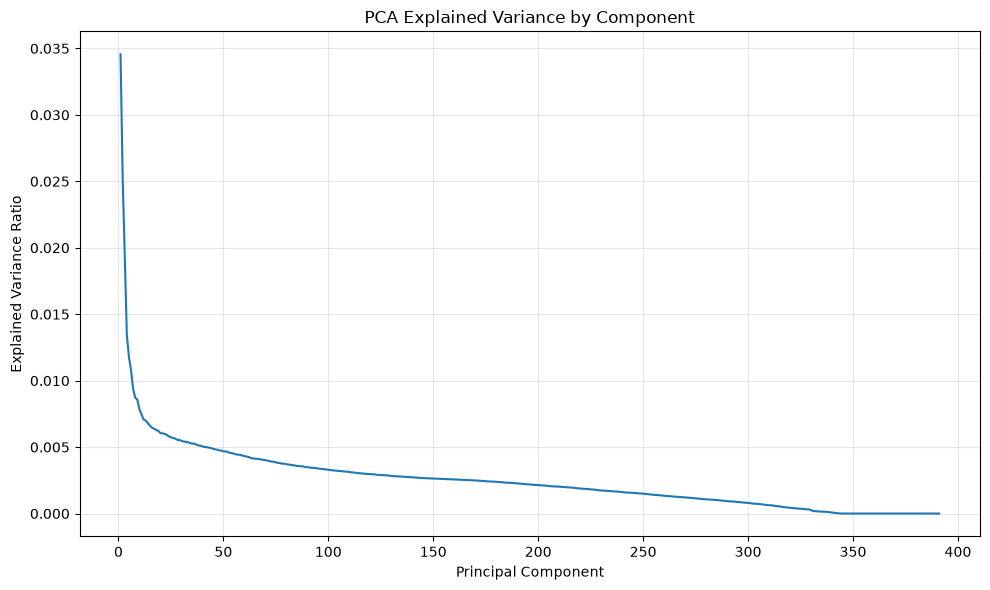

In [33]:
# Plot the individual explained variance of the principal components.
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=pca_variance,
    x="component",
    y="explained_variance_ratio",
    ax=ax,
)

ax.set(
    title="PCA Explained Variance by Component",
    xlabel="Principal Component",
    ylabel="Explained Variance Ratio",
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The explained-variance profile shows that the contribution of individual components decreases as additional components are retained.

The leading component explains the largest individual proportion of variance, but the contribution is not large enough to represent the complete survey structure by itself. The subsequent components continue to contribute meaningful variance.

This indicates that the selected survey representation is not reducible to only a very small number of dominant dimensions.

The dimensionality-reduction decision therefore needs to consider cumulative variance rather than relying on the first few components alone.

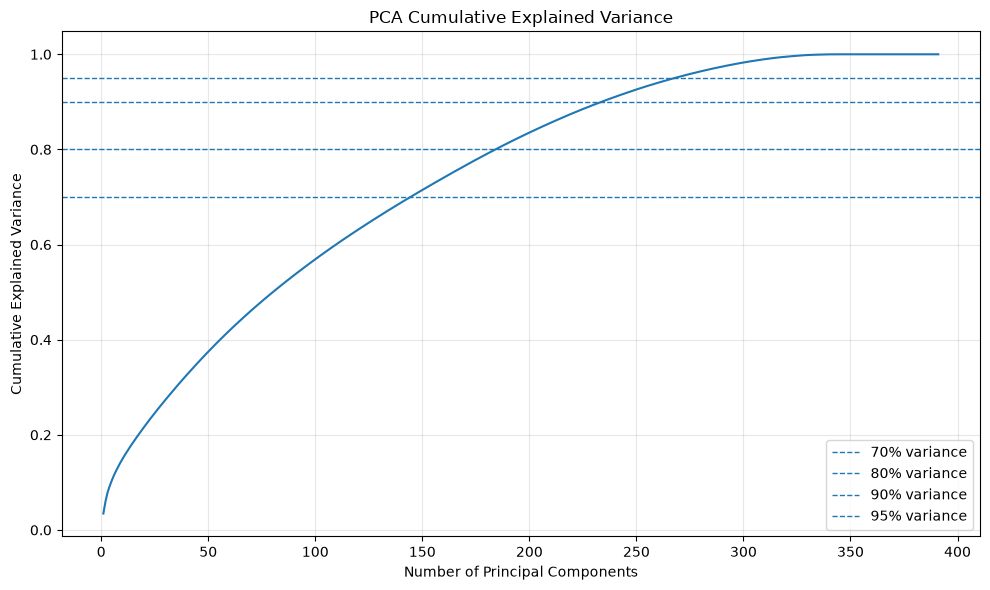

In [35]:
# Plot cumulative explained variance and mark the variance-retention
# reference levels used to assess the practical dimensionality reduction.
variance_thresholds = [0.70, 0.80, 0.90, 0.95]

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=pca_variance,
    x="component",
    y="cumulative_explained_variance",
    ax=ax,
)

for threshold in variance_thresholds:
    ax.axhline(
        threshold,
        linestyle="--",
        linewidth=1,
        label=f"{threshold:.0%} variance",
    )

ax.set(
    title="PCA Cumulative Explained Variance",
    xlabel="Number of Principal Components",
    ylabel="Cumulative Explained Variance",
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# Determine the first component count at or above each cumulative-variance
# reference level from the single complete PCA solution.
variance_threshold_table = pd.DataFrame(
    {
        "variance_threshold": variance_thresholds,
        "components_required": [
            int(
                np.searchsorted(
                    pca_variance["cumulative_explained_variance"].to_numpy(),
                    threshold,
                )
                + 1
            )
            for threshold in variance_thresholds
        ],
    }
)

variance_threshold_table

,variance_threshold,components_required
0,0.70,145
1,0.80,185
2,0.90,234
3,0.95,268


### Interpretation

The cumulative-variance analysis provides empirical reference points for the dimensionality of the selected feature space.

The thresholds are diagnostic reference points rather than independent modelling rules. They show how many principal components are required to retain progressively larger proportions of the variance.

The important result is the trade-off between dimensionality reduction and information retention.

A representation that retains substantially more variance while using fewer dimensions provides a practical candidate for subsequent clustering, but its usefulness must still be assessed through the clustering experiments in Notebook 04.

## 9. Primary PCA Representation

### Decision

The primary PCA representation will retain the first components required to reach the **90% cumulative explained-variance reference level**.

The critical implementation detail is that these components are taken directly from the **same complete PCA solution** used to calculate the variance profile.

PCA is therefore **not fitted a second time** with the selected number of components.

This ensures that the reported cumulative variance and the retained PCA representation refer to exactly the same fitted decomposition.

In [37]:
# Select the first component count that reaches the project's 90% cumulative
# explained-variance reference point from the already fitted PCA solution.
pca_component_count = int(
    variance_threshold_table.loc[
        variance_threshold_table["variance_threshold"]
        == PCA_VARIANCE_THRESHOLD,
        "components_required",
    ].iloc[0]
)

# Extract the selected components from the existing full PCA transformation.
X_pca = X_pca_full.iloc[:, :pca_component_count].copy()

# Calculate the retained variance directly from the same fitted PCA model.
pca_retained_variance = pca_full.explained_variance_ratio_[
    :pca_component_count
].sum()

# Verify that the selected representation actually reaches the requested
# variance threshold. This prevents a mismatch between the threshold table
# and the final PCA representation.
if pca_retained_variance < PCA_VARIANCE_THRESHOLD:
    raise ValueError(
        "The selected PCA representation does not reach the requested "
        "cumulative explained-variance threshold."
    )

print(
    f"Primary PCA representation: "
    f"{X_pca.shape[0]:,} observations x "
    f"{X_pca.shape[1]:,} components."
)

print(
    "Cumulative explained variance retained: "
    f"{pca_retained_variance:.0%}."
)

Primary PCA representation: 1,433 observations x 234 components.
Cumulative explained variance retained: 90%.


In [38]:
# Report the complete dimensionality-reduction decision without repeating
# the same information elsewhere in the notebook.
selected_features = X_selected_scaled.shape[1]
pca_features = X_pca.shape[1]

print(
    f"Selected standardized features: {selected_features:,}"
)

print(
    f"Primary PCA components: {pca_features:,}"
)

print(
    f"Variance retained: {pca_retained_variance:.0%}"
)

Selected standardized features: 391
Primary PCA components: 234
Variance retained: 90%


### Interpretation

The primary PCA representation is defined by the **90% cumulative explained-variance reference level**.

The selected components are extracted directly from the complete PCA solution. Consequently, the reported retained variance is mathematically consistent with the variance-threshold analysis and does not depend on a second PCA fit.

This provides a substantial dimensionality reduction while retaining at least the 90% reference level of variance represented in the selected standardized feature space.

The result should not be interpreted as evidence that the survey is intrinsically low-dimensional. The number of components required to reach the reference level indicates that the information remains distributed across many dimensions.

The PCA representation is therefore a **reduced but still relatively high-dimensional representation** that will be evaluated against the no-reduction representation during clustering.

## 10. Principal Component Loadings

### Question

What types of prepared features contribute most strongly to the leading principal components?

### Why

Explained variance shows how much information each component captures, but it does not explain what that information represents.

The loading analysis connects the transformed PCA dimensions back to the original prepared features.

The strongest absolute loadings across the first five components are examined to keep the analysis focused on the most influential variables.

In [39]:
# Convert PCA component coefficients into a feature-level loading table that
# remains traceable to the selected prepared feature names.
pca_loadings = pd.DataFrame(
    pca_full.components_,
    columns=X_selected_scaled.columns,
    index=[
        f"PC{i}"
        for i in range(1, pca_full.n_components_ + 1)
    ],
)

# Identify the strongest absolute loadings across the first five components.
leading_loadings = (
    pca_loadings.iloc[:5]
    .T
    .assign(
        maximum_absolute_loading=lambda data: data.abs().max(axis=1)
    )
    .sort_values(
        "maximum_absolute_loading",
        ascending=False,
    )
)

display(
    leading_loadings.head(20).style.format(
        {
            "PC1": "{:.3f}",
            "PC2": "{:.3f}",
            "PC3": "{:.3f}",
            "PC4": "{:.3f}",
            "PC5": "{:.3f}",
            "maximum_absolute_loading": "{:.3f}",
        }
    )
)

,PC1,PC2,PC3,PC4,PC5,maximum_absolute_loading
categorical__Did your previous employers provide resources to learn more about mental health issues and how to seek help?_None did,-0.037,0.047,0.077,0.285,0.053,0.285
categorical__Do you believe your productivity is ever affected by a mental health issue?_Missing,0.261,-0.069,0.013,0.043,-0.003,0.261
categorical__Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?_None did,-0.039,0.016,0.057,0.236,0.067,0.236
"categorical__If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?_Missing",0.233,-0.005,0.033,-0.021,-0.020,0.233
categorical__Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?_No,0.228,-0.021,-0.024,0.051,0.027,0.228
"categorical__If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?_Not applicable to me",0.053,0.223,0.077,-0.086,-0.062,0.223
categorical__Did your previous employers provide resources to learn more about mental health issues and how to seek help?_Some did,0.033,-0.066,-0.099,-0.222,0.064,0.222
categorical__Were you aware of the options for mental health care provided by your previous employers?_N/A (not currently aware),-0.001,0.104,0.077,0.221,0.063,0.221
"categorical__If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?_Not applicable to me",0.052,0.220,0.097,-0.091,-0.031,0.220
categorical__Have you been diagnosed with a mental health condition by a medical professional?_Yes,-0.044,-0.219,-0.088,0.087,0.025,0.219


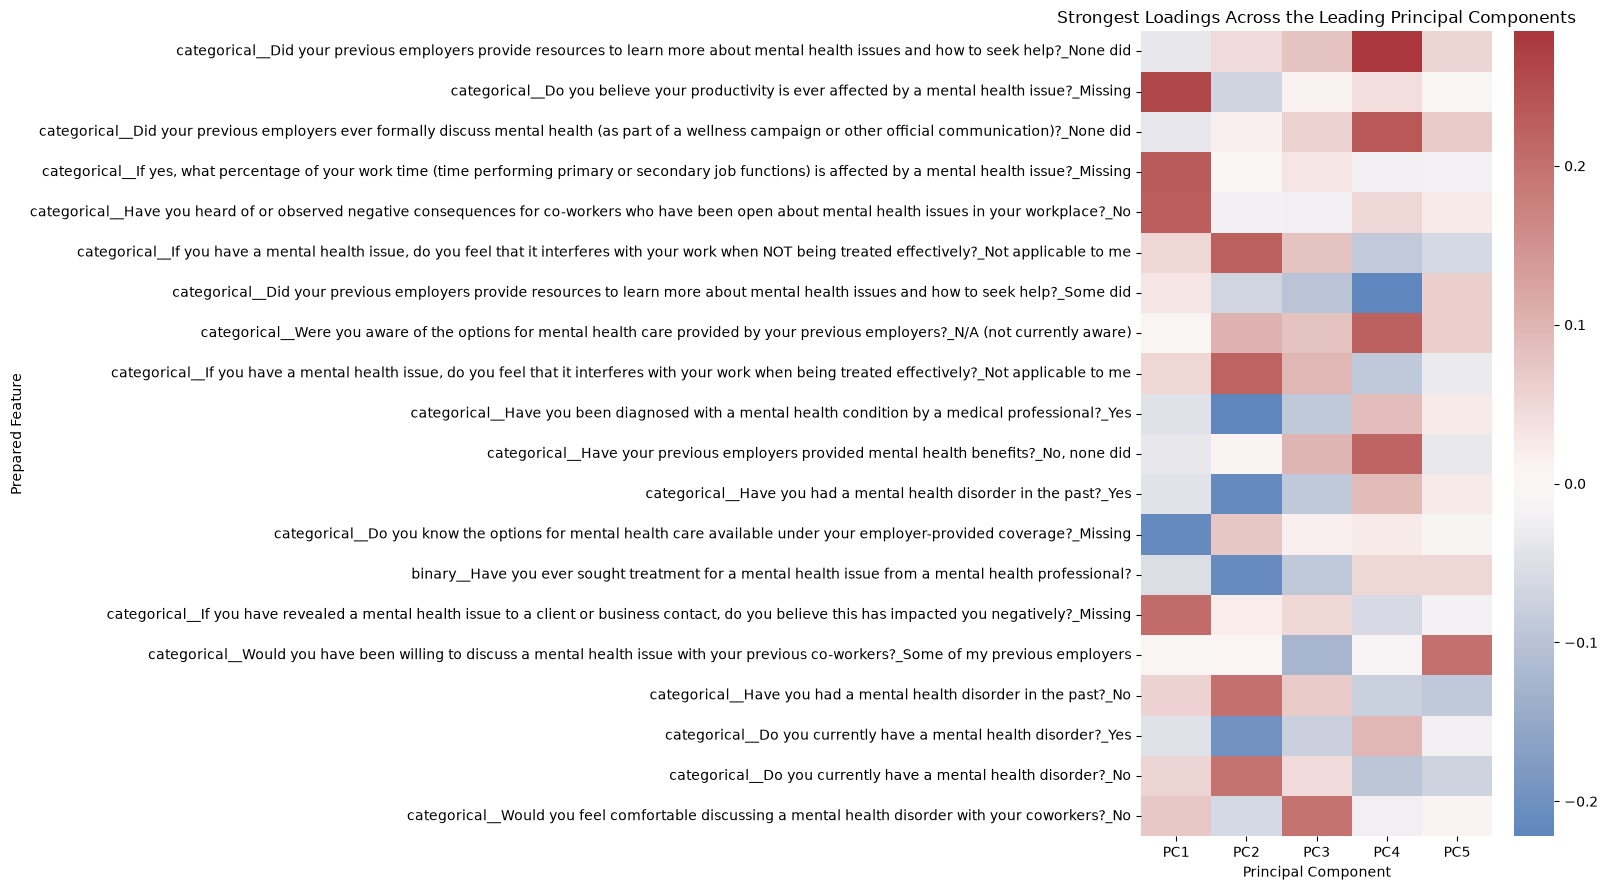

In [41]:
# Visualize only the strongest loading patterns across the leading components.
loading_matrix = leading_loadings.head(20).drop(
    columns="maximum_absolute_loading"
)

fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    loading_matrix,
    cmap="vlag",
    center=0,
    ax=ax,
)

ax.set(
    title="Strongest Loadings Across the Leading Principal Components",
    xlabel="Principal Component",
    ylabel="Prepared Feature",
)

plt.tight_layout()
plt.show()

### Interpretation

The loading analysis shows that the leading principal components combine multiple survey-response patterns rather than representing single original variables.

The strongest contributions include variables associated with:

- workplace mental-health support and resources;
- employer communication about mental health;
- mental-health disclosure;
- previous-employer experiences;
- diagnosed mental-health conditions;
- work interference associated with mental-health issues;
- geographical response patterns;
- response-completeness indicators.

Several of the strongest loadings are **missing-category indicators**.

This is important because it demonstrates that some of the major variation captured by PCA reflects not only substantive survey responses but also differences in response completeness.

The principal components should therefore not be assigned simplistic labels such as "mental-health severity" or "workplace support". Each component represents a weighted combination of many encoded variables.

The loading analysis is consequently used to understand the composition of the transformed feature space rather than to assign clinical or psychological meanings to individual components.

## 11. PCA Two-Dimensional Projection

### Question

What structure is visible when respondents are projected onto the first two principal components?

### Why

The complete PCA representation is high-dimensional. A two-dimensional projection provides a visual diagnostic of the leading directions of variation.

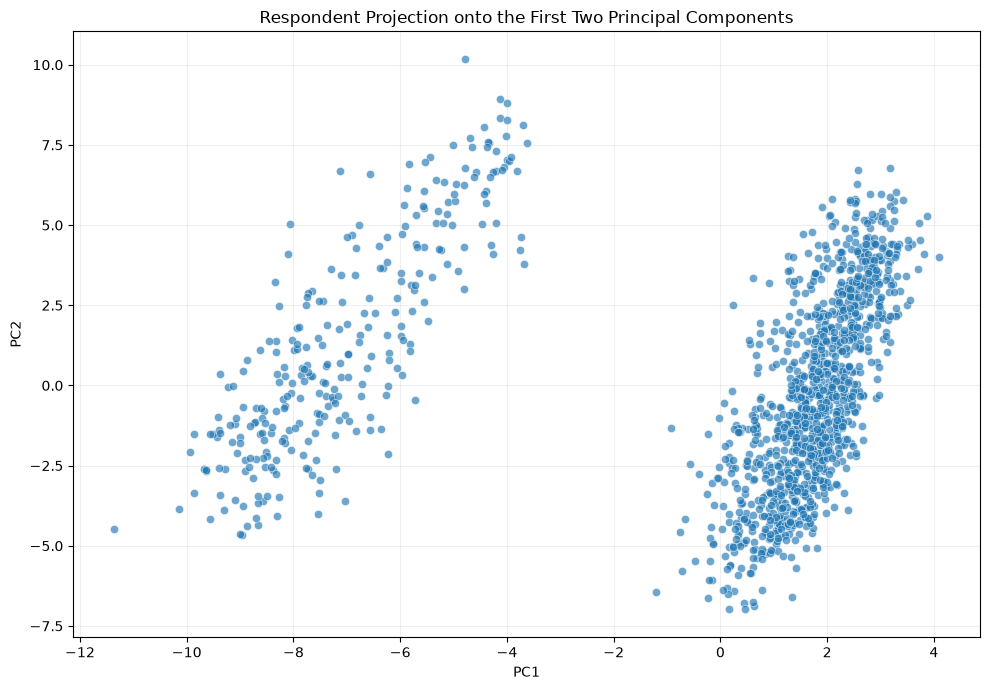

In [43]:
# Use the first two principal components only for visualization. This does not
# replace the full 234-component PCA representation used for clustering.
pca_projection = pd.DataFrame(
    X_pca_full.iloc[:, :2].to_numpy(),
    columns=["PC1", "PC2"],
    index=X_pca_full.index,
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=pca_projection,
    x="PC1",
    y="PC2",
    s=35,
    alpha=0.65,
    ax=ax,
)

ax.set(
    title="Respondent Projection onto the First Two Principal Components",
    xlabel="PC1",
    ylabel="PC2",
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interpretation

The two-dimensional PCA projection reveals visible structure in the respondent space rather than a completely homogeneous cloud.

The observations show areas of greater concentration together with more dispersed observations along the leading principal-component directions.

These patterns indicate that the prepared feature space contains geometric structure that warrants formal clustering analysis.

However, the projection cannot establish how many clusters exist. Apparent visual groupings in two dimensions may arise from projection effects and may not correspond to distinct groups in the full feature space.

## 12. Multidimensional Scaling

### Question

Does a distance-based dimensionality-reduction method reveal a similar or different structure from PCA?

### Method

Multidimensional Scaling (MDS) is evaluated as a complementary nonlinear dimensionality-reduction method.

MDS attempts to represent the relationships between observations by preserving their pairwise distances as closely as possible in a lower-dimensional space.

The MDS representation is generated from the standardized selected feature space.

### Why

PCA and MDS preserve different properties:

- PCA is based on variance and linear transformations.
- MDS focuses on the distances between observations.

Using MDS as a complementary representation therefore provides a different perspective on the geometry of the prepared data.

In [44]:
# Fit a two-dimensional metric MDS representation using the standardized,
# redundancy-reduced feature space.
mds_model, X_mds_array = fit_mds(
    X_selected_scaled,
    n_components=2,
    random_state=RANDOM_STATE,
)

X_mds = pd.DataFrame(
    X_mds_array,
    columns=["MDS1", "MDS2"],
    index=X_selected_scaled.index,
)

mds_stress = float(mds_model.stress_)

print(
    f"MDS representation: "
    f"{X_mds.shape[0]:,} observations x "
    f"{X_mds.shape[1]} dimensions."
)

print(
    f"MDS stress: {mds_stress:,.4f}"
)

C:\Users\User\Documents\Projects\mental-health-in-tech-ml\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


MDS representation: 1,433 observations x 2 dimensions.
MDS stress: 89,067,737.8138


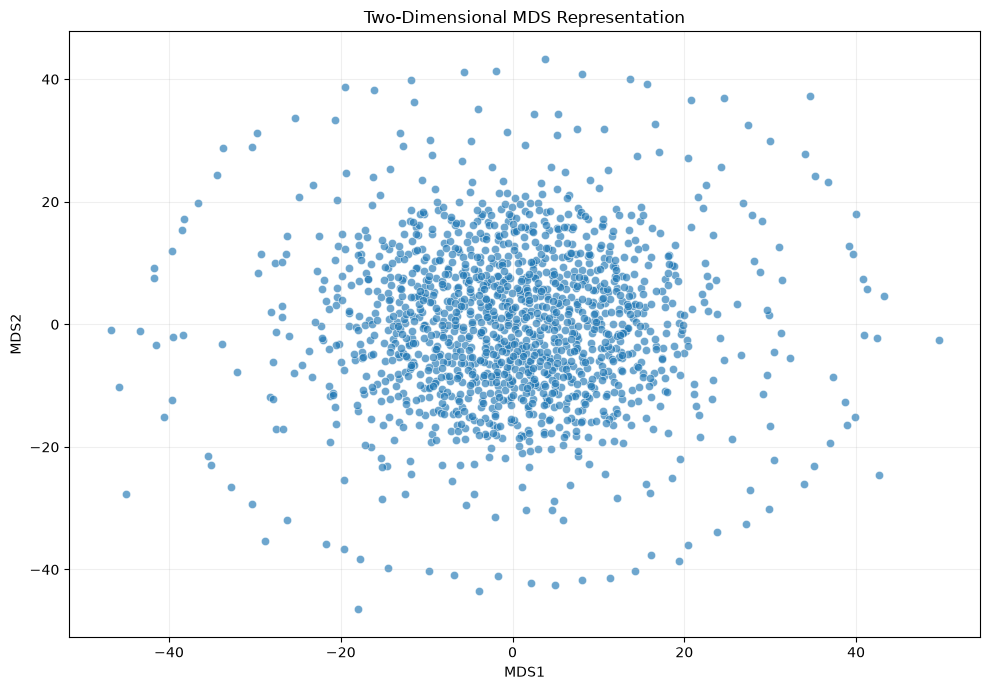

In [46]:
# Visualize the two-dimensional MDS representation as a complementary view
# of respondent-level distance structure.
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=X_mds,
    x="MDS1",
    y="MDS2",
    s=35,
    alpha=0.65,
    ax=ax,
)

ax.set(
    title="Two-Dimensional MDS Representation",
    xlabel="MDS1",
    ylabel="MDS2",
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interpretation

The MDS representation provides a complementary view of the respondent space from a distance-based perspective.

Its geometry differs from the PCA projection. Rather than reproducing the same directional structure shown by the first two principal components, the MDS representation shows a dense central population together with broader dispersion and peripheral observations.

This difference is not evidence that one method is correct and the other is incorrect. PCA and MDS optimize different properties of the data.

The MDS stress value is retained as a diagnostic of the distance-preservation objective. Because the value reported here is raw stress, its absolute magnitude should not be interpreted independently as a universal measure of embedding quality.

The MDS representation is therefore retained as a **complementary representation**, rather than replacing the PCA representation as the primary reduced feature space.

## 13. Locally Linear Embedding Consideration

### Question

Is there sufficient methodological justification to introduce Locally Linear Embedding (LLE) into the dimensionality-reduction experiment?

### Methodological basis

LLE is a nonlinear manifold-learning method that focuses on preserving local neighbourhood relationships when representing observations in a lower-dimensional space.

The method is also sensitive to noise and outliers because its representation depends on local nearest-neighbour relationships.

### Dataset evidence

The selected analytical representation is dominated by:

- binary features;
- one-hot encoded categorical features;
- categorical missingness indicators;
- a continuous age feature.

These variables describe discrete survey-response states rather than measurements for which a smooth nonlinear manifold has been established.

The numerical encoding of categorical responses does not, by itself, demonstrate that respondents lie on a smooth locally linear manifold.

The PCA and MDS analyses also do not provide sufficient evidence that such a manifold assumption is necessary for representing the respondent space.

### Decision

**LLE will not be implemented.**

This is a deliberate methodological decision rather than an omission.

Implementing LLE simply because it is available would introduce an additional nonlinear-manifold assumption without sufficient evidence that the assumption is appropriate for this dataset.

PCA therefore remains the primary reduced representation, while MDS provides the complementary nonlinear distance-based representation required for comparison.

LLE remains documented as a considered alternative, satisfying the project's requirement to justify why dimensionality-reduction alternatives are or are not used.

## 14. Final Analytical Representations

The dimensionality-reduction stage now produces the representations required for the clustering experiments.

The representations have different purposes:

- the selected standardized features provide the **no-reduction baseline**;
- the PCA representation provides the **primary reduced feature space**;
- the MDS representation provides a **complementary two-dimensional distance-based representation**.

In [47]:
# Validate that every final representation retains the same respondents and
# contains only finite numerical values before saving the analytical outputs.
representations = {
    "selected_scaled": X_selected_scaled,
    "pca": X_pca,
    "mds": X_mds,
}

for name, representation in representations.items():
    if representation.shape[0] != original_observations:
        raise ValueError(
            f"{name} representation changed the respondent count."
        )

    if not np.isfinite(representation.to_numpy()).all():
        raise ValueError(
            f"{name} representation contains non-finite values."
        )

print("Final representation validation passed.")

Final representation validation passed.


In [48]:
# Persist the representations required by the subsequent clustering stage.
output_directory = Path("../data/processed")
output_directory.mkdir(parents=True, exist_ok=True)

X_selected.to_csv(
    output_directory / "mental_health_selected.csv", index=False
)

X_selected_scaled.to_csv(
    output_directory / "mental_health_selected_scaled.csv", index=False
)

X_pca.to_csv(
    output_directory / "mental_health_pca.csv", index=False
)

X_mds.to_csv(
    output_directory / "mental_health_mds.csv", index=False
)

print("Final analytical representations saved:")
print("- mental_health_selected.csv")
print("- mental_health_selected_scaled.csv")
print("- mental_health_pca.csv")
print("- mental_health_mds.csv")

Final analytical representations saved:
- mental_health_selected.csv
- mental_health_selected_scaled.csv
- mental_health_pca.csv
- mental_health_mds.csv


## 15. Final Dimensionality-Reduction Decision

The dimensionality-reduction stage establishes the following analytical representations:

| Representation | Observations | Dimensions | Role |
|---|---:|---:|---|
| Prepared analytical matrix | 1,433 | 495 | Input from Notebook 02 |
| Selected features | 1,433 | Determined by filtering | Redundancy-reduced representation |
| Standardized selected features | 1,433 | Same as selected | **No-reduction clustering baseline** |
| PCA representation | 1,433 | Determined by 90% variance reference | **Primary reduced representation** |
| MDS representation | 1,433 | 2 | **Complementary distance-based representation** |

The analytical progression is therefore determined from the actual feature-selection and PCA results rather than from hard-coded dimensionality values.

The primary PCA representation uses the first components of the **same complete PCA solution** used to calculate cumulative explained variance. This ensures that the selected component count and the reported retained variance are internally consistent.

LLE is not implemented because the dataset and preceding dimensionality-reduction results do not provide sufficient justification for introducing its nonlinear manifold assumption.

The selected standardized representation and PCA representation will be used in the clustering experiments. The MDS representation remains available as a complementary analytical view.

# Final Conclusion

The dimensionality-reduction stage demonstrates that the prepared survey representation contains substantial redundancy and remains relatively high-dimensional even after redundant features are removed.

The original analytical matrix contains 1,433 respondents and 495 prepared numerical features. Zero-variance filtering first removes any features that cannot distinguish respondents, after which correlation-based filtering addresses highly redundant information using an absolute Pearson correlation threshold of 0.95.

The resulting selected representation is standardized before dimensionality reduction because the analytical feature space combines continuous, binary, and one-hot encoded variables.

PCA is fitted once across the complete standardized selected representation. The resulting explained-variance profile shows that the information is distributed across many principal components rather than being concentrated into only a few dimensions.

The primary PCA representation is defined using the first components required to reach the **90% cumulative explained-variance reference level**. Importantly, these components are extracted directly from the same complete PCA solution used to calculate the variance profile. No second PCA fit is performed, ensuring that the retained variance and component count are internally consistent.

The PCA loading analysis shows that the leading components combine multiple workplace, mental-health, support, disclosure, geographical, and response-completeness patterns. Several strong loadings are associated with missing-category indicators, meaning that some variation captured by PCA reflects differences in response completeness as well as substantive survey responses. The principal components should therefore not be interpreted as individual psychological or clinical constructs.

The two-dimensional PCA projection reveals visible structure in the respondent space, but it does not establish a cluster count. Formal clustering is required to determine whether the observed structure corresponds to meaningful groups.

MDS provides a complementary distance-based representation. Its two-dimensional geometry differs from the PCA projection, demonstrating that different dimensionality-reduction objectives reveal different aspects of the respondent space. The MDS stress value is retained as a diagnostic of the distance-preservation objective rather than being treated as an independent universal measure of embedding quality.

LLE was considered against the criteria and the characteristics of the prepared dataset. The representation is dominated by discrete binary and one-hot encoded survey variables, and the analysis does not provide sufficient evidence for a smooth locally linear manifold structure. LLE is therefore not implemented. Introducing it without sufficient justification would add methodological complexity without a demonstrated analytical need.

The clustering stage now has:

1. a standardized selected-feature representation for the **no-reduction baseline**;
2. a PCA representation based on the observed **90% cumulative-variance reference** as the **primary reduced representation**;
3. a two-dimensional MDS representation as a **complementary distance-based representation**.

Notebook 04 can now evaluate **K-Means, Gaussian Mixture Model, Agglomerative Hierarchical Clustering, and DBSCAN** using these established representations.